# Monte Carlo Investment Risk Simulator

**Actuarial Science — Undergraduate Project**

**Author:** Derrick Clinton Ochieng

---

This project uses Monte Carlo simulation to model uncertainty in
investment returns and analyse investment risk over a 10-year period.

## 1. Introduction

This project uses Monte Carlo simulation to model the uncertainty
of investment returns over a 10-year period.

The model simulates 10,000 possible investment paths using assumed
annual expected returns and volatility. The resulting distribution
of final investment values is then analysed using statistical and
risk measures.

The project also investigates how changes in expected return,
volatility, and inflation affect investment outcomes.

## 1. Objective
1. Simulate possible investment outcomes using Monte Carlo methods.
2. Estimate the probability of reaching a specified investment target.
3. Estimate the probability of ending below the initial investment.
4. Analyse the distribution of simulated final investment values.
5. Investigate the sensitivity of results to expected return and volatility.
6. Examine the effect of inflation on purchasing power.
7. Apply percentile-based risk measures, including VaR and Expected Shortfall.

## 2. Model Assumptions

The model is based on the following assumptions:

| Assumption | Value |
|---|---:|
| Initial investment | KSh 100,000 |
| Investment period | 10 years |
| Number of simulations | 10,000 |
| Expected annual return | 8% |
| Annual volatility | 15% |
| Inflation rate | 5% |
| Target investment value | KSh 200,000 |

### Return Model

Annual investment returns are assumed to follow a normal distribution:

\[
R_t \sim N(\mu, \sigma^2)
\]

where:

- \(\mu = 8\%\) is the expected annual return.
- \(\sigma = 15\%\) is the annual volatility.

The annual returns are assumed to be independent.

### Other Assumptions

The model does not include:

- Investment fees
- Taxes
- Withdrawals or additional contributions
- Changes in investment strategy
- Stochastic inflation

## 3. Model Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Investment assumptions
initial_investment = 100000
n_years = 10
n_simulations = 10000

# Return assumptions
expected_return = 0.08
volatility = 0.15

# Inflation assumption
inflation_rate = 0.05

# Target value
target = 200000

## 4. Monte Carlo Simulation

For each simulation, annual investment returns are generated randomly
from the assumed normal distribution.

The investment is then compounded annually over the 10-year period.

The process is repeated 10,000 times to generate a distribution of
possible final investment values.

In [2]:
# Set a seed so that the simulation is reproducible
np.random.seed(42)

final_values = []

for simulation in range(n_simulations):
    
    returns = np.random.normal(
        expected_return,
        volatility,
        n_years
    )
    
    balance = initial_investment
    
    for r in returns:
        balance = balance * (1 + r)
    
    final_values.append(balance)

print("Number of simulations:", len(final_values))
print("First 5 final values:", final_values[:5])

Number of simulations: 10000
First 5 final values: [np.float64(379485.3532844479), np.float64(63328.00757213378), np.float64(148698.95335496575), np.float64(122979.29645042511), np.float64(139557.76685435954)]


## 5. Summary Statistics

The simulated final investment values are summarised using the mean,
median, and standard deviation.

These measures provide an overview of the centre and variability of
the simulated distribution.

In [3]:
# Summary statistics

mean_value = np.mean(final_values)
median_value = np.median(final_values)
std_value = np.std(final_values)

print(f"Mean final value: KSh {mean_value:,.2f}")
print(f"Median final value: KSh {median_value:,.2f}")
print(f"Standard deviation: KSh {std_value:,.2f}")

Mean final value: KSh 216,997.29
Median final value: KSh 197,943.57
Standard deviation: KSh 101,979.61


## 6. Percentile Analysis

Percentiles are used to examine the range of possible investment
outcomes.

The 5th and 95th percentiles provide an indication of the lower and
upper tails of the simulated distribution.

In [4]:
# Percentile analysis

percentiles = np.percentile(
    final_values,
    [5, 25, 50, 75, 95]
)

print(f"5th percentile:  KSh {percentiles[0]:,.2f}")
print(f"25th percentile: KSh {percentiles[1]:,.2f}")
print(f"50th percentile: KSh {percentiles[2]:,.2f}")
print(f"75th percentile: KSh {percentiles[3]:,.2f}")
print(f"95th percentile: KSh {percentiles[4]:,.2f}")

5th percentile:  KSh 89,638.97
25th percentile: KSh 144,358.47
50th percentile: KSh 197,943.57
75th percentile: KSh 266,870.86
95th percentile: KSh 408,817.70


In [5]:
# Probability of reaching the investment target

probability_target = np.mean(
    np.array(final_values) >= target
)

print(
    f"Probability of reaching KSh {target:,.0f}: "
    f"{probability_target * 100:.2f}%"
)

Probability of reaching KSh 200,000: 49.21%


In [6]:
# Probability of losing money

probability_loss = np.mean(
    np.array(final_values) < initial_investment
)

print(
    f"Probability of ending below the initial investment: "
    f"{probability_loss * 100:.2f}%"
)

Probability of ending below the initial investment: 7.91%


## 7. Distribution of Final Investment Values

The histogram below shows the distribution of final investment values
across the 10,000 simulated investment scenarios.

The initial investment of KSh 100,000 and the target of KSh 200,000
are shown as reference points.

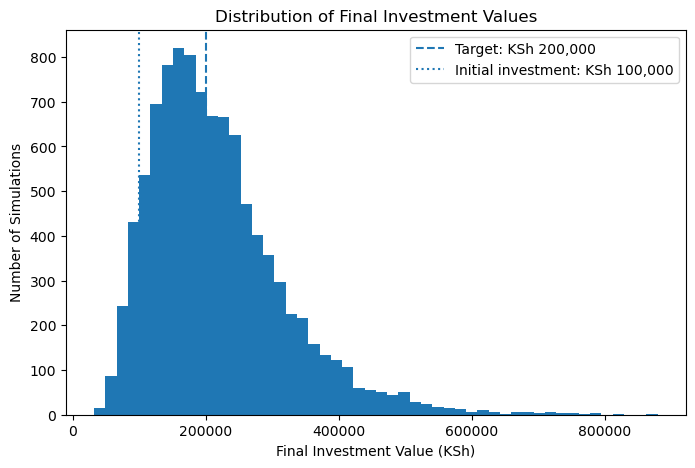

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_values,
    bins=50
)

plt.axvline(
    target,
    linestyle="--",
    label="Target: KSh 200,000"
)

plt.axvline(
    initial_investment,
    linestyle=":",
    label="Initial investment: KSh 100,000"
)

plt.xlabel("Final Investment Value (KSh)")
plt.ylabel("Number of Simulations")
plt.title("Distribution of Final Investment Values")
plt.legend()

plt.show()

## 8. Risk Analysis

Two key probabilities are used to assess investment risk:

1. The probability that the final investment value reaches or exceeds
   the KSh 200,000 target.
2. The probability that the final investment value falls below the
   initial investment of KSh 100,000.

In [8]:
# Probability of reaching the investment target

probability_target = np.mean(
    np.array(final_values) >= target
)

print(
    f"Probability of reaching KSh {target:,.0f}: "
    f"{probability_target * 100:.2f}%"
)

Probability of reaching KSh 200,000: 49.21%


In [9]:
# Probability of losing money

probability_loss = np.mean(
    np.array(final_values) < initial_investment
)

print(
    f"Probability of ending below the initial investment: "
    f"{probability_loss * 100:.2f}%"
)

Probability of ending below the initial investment: 7.91%


## 9. Sensitivity Analysis

Sensitivity analysis examines how changes in the model assumptions
affect investment outcomes.

Two important assumptions are examined:

1. Expected annual return
2. Annual volatility

This helps assess how sensitive the probability of achieving the
investment target is to changes in these assumptions.

### 9.1 Expected Return Sensitivity

The expected annual return is varied from 5% to 11%, while keeping
volatility and all other assumptions constant.

For each expected return, the probability of exceeding the
KSh 200,000 target is estimated using Monte Carlo simulation.

In [10]:
expected_returns = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11]

target_probabilities = []

for expected_return_sensitivity in expected_returns:

    final_values_sensitivity = []

    for simulation in range(n_simulations):

        returns = np.random.normal(
            expected_return_sensitivity,
            volatility,
            n_years
        )

        balance = initial_investment

        for r in returns:
            balance *= (1 + r)

        final_values_sensitivity.append(balance)

    probability = np.mean(
        np.array(final_values_sensitivity) >= target
    )

    target_probabilities.append(probability)

    print(
        f"{expected_return_sensitivity * 100:.0f}% expected return "
        f"→ {probability * 100:.2f}% probability of reaching target"
    )

5% expected return → 25.79% probability of reaching target
6% expected return → 32.59% probability of reaching target
7% expected return → 39.95% probability of reaching target
8% expected return → 48.90% probability of reaching target
9% expected return → 56.89% probability of reaching target
10% expected return → 65.68% probability of reaching target
11% expected return → 72.85% probability of reaching target


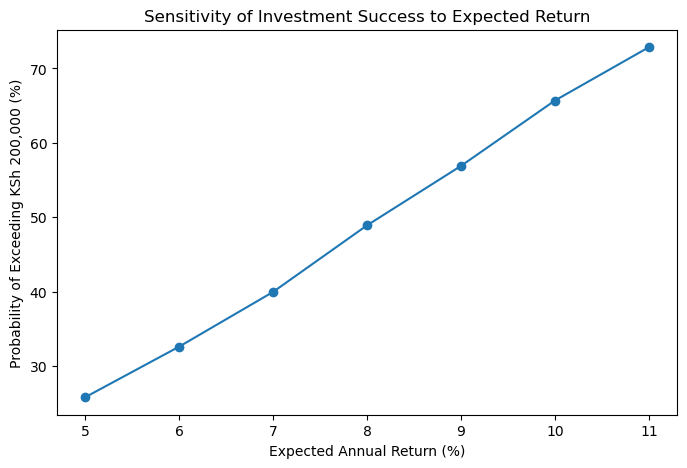

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(expected_returns) * 100,
    np.array(target_probabilities) * 100,
    marker="o"
)

plt.xlabel("Expected Annual Return (%)")
plt.ylabel("Probability of Exceeding KSh 200,000 (%)")
plt.title("Sensitivity of Investment Success to Expected Return")

plt.show()

### 9.2 Volatility Sensitivity

The annual volatility is varied from 5% to 25%, while expected return
and all other assumptions are kept constant.

For each volatility level, the probability of ending below the initial
investment is estimated.

This demonstrates how increasing uncertainty in investment returns
affects downside risk.

In [12]:
# Volatility sensitivity analysis

volatilities = [0.05, 0.10, 0.15, 0.20, 0.25]

loss_probabilities = []

for volatility_sensitivity in volatilities:

    final_values_volatility = []

    for simulation in range(n_simulations):

        returns = np.random.normal(
            expected_return,
            volatility_sensitivity,
            n_years
        )

        balance = initial_investment

        for r in returns:
            balance *= (1 + r)

        final_values_volatility.append(balance)

    probability_loss = np.mean(
        np.array(final_values_volatility) < initial_investment
    )

    loss_probabilities.append(probability_loss)

    print(
        f"{volatility_sensitivity * 100:.0f}% volatility → "
        f"{probability_loss * 100:.2f}% probability of loss"
    )

5% volatility → 0.00% probability of loss
10% volatility → 0.98% probability of loss
15% volatility → 7.14% probability of loss
20% volatility → 16.88% probability of loss
25% volatility → 27.27% probability of loss


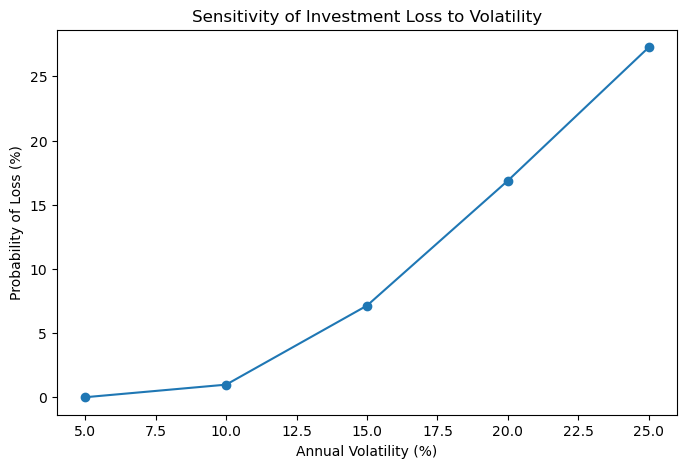

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(volatilities) * 100,
    np.array(loss_probabilities) * 100,
    marker="o"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Probability of Loss (%)")
plt.title("Sensitivity of Investment Loss to Volatility")

plt.show()

## 10. Inflation Analysis

The previous analysis considered nominal investment values. However,
nominal values do not account for changes in purchasing power.

An inflation rate of 5% per year is assumed. The simulated final
investment values are converted into today's purchasing power using:

Real Value = Nominal Value / (1 + inflation rate)^n

This allows the nominal and real investment outcomes to be compared.

In [14]:
# Inflation-adjusted values

real_values = (
    np.array(final_values)
    / (1 + inflation_rate) ** n_years
)

print(f"Mean real value: KSh {np.mean(real_values):,.2f}")
print(f"Median real value: KSh {np.median(real_values):,.2f}")
print(f"5th percentile: KSh {np.percentile(real_values, 5):,.2f}")
print(f"95th percentile: KSh {np.percentile(real_values, 95):,.2f}")

Mean real value: KSh 133,217.51
Median real value: KSh 121,520.18
5th percentile: KSh 55,030.55
95th percentile: KSh 250,978.61


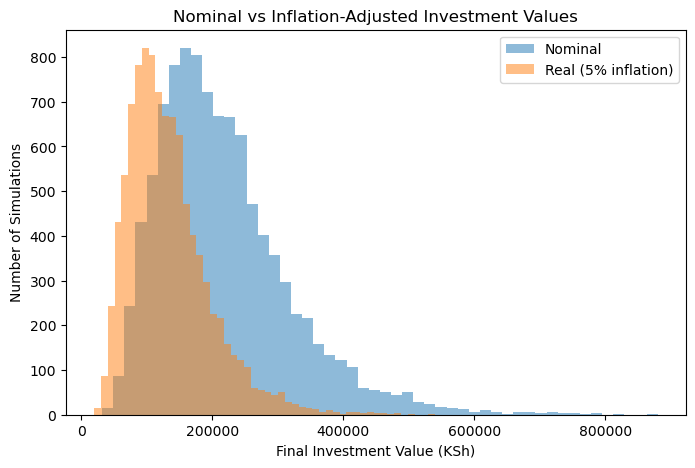

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_values,
    bins=50,
    alpha=0.5,
    label="Nominal"
)

plt.hist(
    real_values,
    bins=50,
    alpha=0.5,
    label="Real (5% inflation)"
)

plt.xlabel("Final Investment Value (KSh)")
plt.ylabel("Number of Simulations")
plt.title("Nominal vs Inflation-Adjusted Investment Values")
plt.legend()

plt.show()

## 11. Value at Risk and Expected Shortfall

Percentile-based measures can be used to examine the downside tail
of the simulated investment distribution.

The 5th percentile is used as a VaR-style threshold. Expected
Shortfall then calculates the average final investment value among
the worst 5% of simulated outcomes.

In [16]:
# 5% VaR-style threshold

var_5 = np.percentile(final_values, 5)

print(f"5% VaR threshold: KSh {var_5:,.2f}")

5% VaR threshold: KSh 89,638.97


In [17]:
# 5% Expected Shortfall

worst_5_percent = np.array(final_values)[
    np.array(final_values) <= var_5
]

expected_shortfall_5 = np.mean(worst_5_percent)

print(
    f"5% Expected Shortfall: "
    f"KSh {expected_shortfall_5:,.2f}"
)

5% Expected Shortfall: KSh 75,123.06


## 12. Model Limitations

The model provides a simplified representation of investment
uncertainty and has several limitations.

1. Annual returns are assumed to follow a normal distribution.
2. Annual returns are assumed to be independent.
3. Expected return is assumed to remain constant throughout the
   investment period.
4. Volatility is assumed to remain constant.
5. Inflation is assumed to remain constant at 5% per year.
6. Investment fees and taxes are excluded.
7. No additional contributions or withdrawals are included.
8. The model does not account for changes in investment strategy.
9. Real financial returns may exhibit skewness, heavy tails,
   autocorrelation and changing volatility.
10. Monte Carlo results are estimates and may vary with the number
    of simulations and random-number generation.

## 13. Conclusion

The Monte Carlo simulation estimated a 49.21% probability of the
investment reaching or exceeding KSh 200,000 after 10 years, under
the assumed model parameters.

The probability of ending below the initial investment of
KSh 100,000 was estimated at 7.91%.

The sensitivity analysis demonstrated that changes in expected return
and volatility can have a substantial effect on investment outcomes.
In particular, higher volatility increased the probability of loss
when expected return was held constant.

The inflation analysis demonstrated that nominal investment growth
does not necessarily translate into the same growth in purchasing
power. With an assumed annual inflation rate of 5%, the real value
of the investment was substantially lower than its nominal value.

The 5% VaR-style threshold and Expected Shortfall provided additional
measures of downside risk by examining the lower tail of the
simulated distribution.

Overall, the project demonstrates how Monte Carlo simulation can be
used to model uncertainty and quantify investment risk. It combines
probability, financial mathematics, statistics and programming to
analyse a range of possible investment outcomes.